# 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

# 2. Импорт данных

In [2]:
path = './datasets/titles_to_categories.csv'
df = pd.read_csv(path)
f = df.to_numpy()
df.head()

,title,category_name
0,"Green Leaf WW3D Wonder Extension Cord Winder, ...",Industrial Scientific
1,8pcs Toilet Seat Bumpers Universal Toilet Repl...,Industrial Scientific
2,YaeCCC 19 Pcs Hole Saw Kit 3/4''(19mm)- 6''(15...,Industrial Scientific
3,LLPT Butyl Putty Tape White 1 Inch x 33Ft Tigh...,Industrial Scientific
4,"Lightbeam 16"" Long Stem Deep Fry Thermometer w...",Industrial Scientific


In [3]:
m,n = df.shape

category = set()

for line in f:
    category.add(line[1])

print(f'{m=}, {n=}, categorys={len(category)}')

m=5389901, n=2, categorys=726


Набор данных состоит из $5389901$ строк и $2$ столбцов в текстовом формате: заголовока, содержащего ключевые слова, относящиеся к товару ($title$), и его категории ($category\_name$ (всего $726$ категорий). 

# 3. Проверка на пропущенные значения

In [4]:
n = 0
for line in f:
    if line[0] == None or line[0] == None:
        n += 1
        break

if n:
    print('Есть строки с пропущенными значениями')
else:
    print('Нет строк с пропущенными значениями')

Нет строк с пропущенными значениями


## 4.1. Анализ распределения классов

In [27]:
vc = df['category_name'].value_counts()

print(f"Самые частые классы:\n{vc.head(10)}")
print(f"\nСамые редкие классы:\n{vc.tail(10)}")

Самые частые классы:
category_name
Sports & Outdoors     720050
Baby                   36154
Men's Shoes            32143
Women's Handbags       29934
Women's Shoes          28668
Handmade Jewellery     28666
Men's Watches          28483
Boys                   27897
Handmade Artwork       27358
Women's Jewelry        26481
Name: count, dtype: int64

Самые редкие классы:
category_name
Smart Home Security & Lighting                    54
Golf Shoes                                        53
Lighting                                          50
Smart Home: Voice Assistants and Hubs             43
Smart Home: New Smart Devices                     41
Garment Bags                                      39
Gift Cards                                        29
Smart Speakers                                    25
Smart Home Thermostats - Compatibility Checker    22
Cameras                                           12
Name: count, dtype: int64


In [38]:
print(f"\nСтатистика распределения классов:")
print(f"Медианное количество примеров на класс: {vc.median():.2f}")
print(f"Среднее количество примеров на класс: {vc.mean():.2f}")
print(f"Min примеров в классе: {vc.min()}")
print(f"Max примеров в классе: {vc.max()}")
print(f"Среднеквадратичное отклонение: {vc.std():.2f}")
print(f"Коэффициент ассиметрии: {stats.skew(vc):.2f}")
print(f"Коэффициент эксцесса: {stats.kurtosis(vc):.2f}")


Статистика распределения классов:
Медианное количество примеров на класс: 6128.00
Среднее количество примеров на класс: 7424.11
Min примеров в классе: 12
Max примеров в классе: 720050
Среднеквадратичное отклонение: 27082.07
Коэффициент ассиметрии: 25.16
Коэффициент эксцесса: 659.20


## 4.2. Анализ описаний товаров

In [232]:
lens = pd.Series(np.array([len(str) for str in df['title']]))

result = vc.to_frame().reset_index()
result.columns = ['category_name', 'ncount']
types = result.to_numpy()
types_name = list(types[:, 0])

for i, l in enumerate(lens):
    i = types_name.index(f[i, 1])
    avg_lens[i] += l

for i, n in enumerate(vc):
    avg_lens[i] /= n

avg_lens = pd.Series(avg_lens)

In [253]:
avg_lens

0      118.151006
1      105.109534
2       60.466337
3       87.359636
4       63.403705
          ...    
721     79.079570
722     55.220017
723    107.619264
724    112.719102
725    184.889468
Length: 726, dtype: float64

In [254]:
vc.to_numpy()

array([720050,  36154,  32143,  29934,  28668,  28666,  28483,  27897,
        27358,  26481,  26067,  25349,  25258,  24404,  23235,  22912,
        22701,  22245,  22054,  21859,  21718,  21444,  20998,  20949,
        20805,  19821,  18990,  18749,  18724,  18674,  18582,  18548,
        18482,  18414,  18275,  18176,  18168,  18020,  17867,  17769,
        17181,  17132,  16996,  16976,  16802,  16684,  16535,  16506,
        16469,  16433,  16348,  16319,  16255,  16150,  16088,  16055,
        16019,  15841,  15680,  15382,  15319,  15220,  14983,  14927,
        14563,  14560,  14419,  14225,  13885,  13878,  13819,  13778,
        13691,  13471,  13350,  13223,  13016,  12892,  12671,  12647,
        12616,  12315,  11943,  11942,  11689,  11687,  11546,  11266,
        11088,  10963,  10725,  10478,  10397,  10225,  10017,   9973,
         9897,   9799,   9735,   9703,   9693,   9648,   9624,   9445,
         9437,   9415,   9387,   9386,   9348,   9342,   9341,   9336,
      

In [235]:
# print(f"\nСтатистика распределения длин заголовков:")
# print(f"Медианное количество длина описания: {lens.median():.2f}")
# print(f"Среднее длина описания: {lens.mean():.2f}")
# print(f"Min длина описания: {lens.min()}")
# print(f"Max длина описания: {lens.max()}")
# print(f"Среднеквадратичное отклонение: {lens.std():.2f}")
# print(f"Коэффициент ассиметрии: {stats.skew(lens):.2f}")
# print(f"Коэффициент эксцесса: {stats.kurtosis(lens):.2f}")

In [237]:
print(f"\nСтатистика распределения средней длины заголовков (в символах) для каждого класса:")
print(f"Медианное количество слов в описании: {avg_lens.median():.2f}")
print(f"Среднее количество слов в описании: {avg_lens.mean():.2f}")
print(f"Min число слов в описании: {avg_lens.min()}")
print(f"Max число слов в описании: {avg_lens.max()}")
print(f"Среднеквадратичное отклонение: {avg_lens.std():.2f}")
print(f"Коэффициент ассиметрии: {stats.skew(avg_lens):.2f}")
print(f"Коэффициент эксцесса: {stats.kurtosis(avg_lens):.2f}")


Статистика распределения средней длины заголовков (в символах) для каждого класса:
Медианное количество слов в описании: 126.41
Среднее количество слов в описании: 123.53
Min число слов в описании: 45.4045696334127
Max число слов в описании: 184.8894675925926
Среднеквадратичное отклонение: 24.34
Коэффициент ассиметрии: -0.70
Коэффициент эксцесса: 0.60


In [15]:
words = dict()
for s in df ['title']:
    for word in s.split():
        words[word] = 0

2789970

# 5. Гистограммы

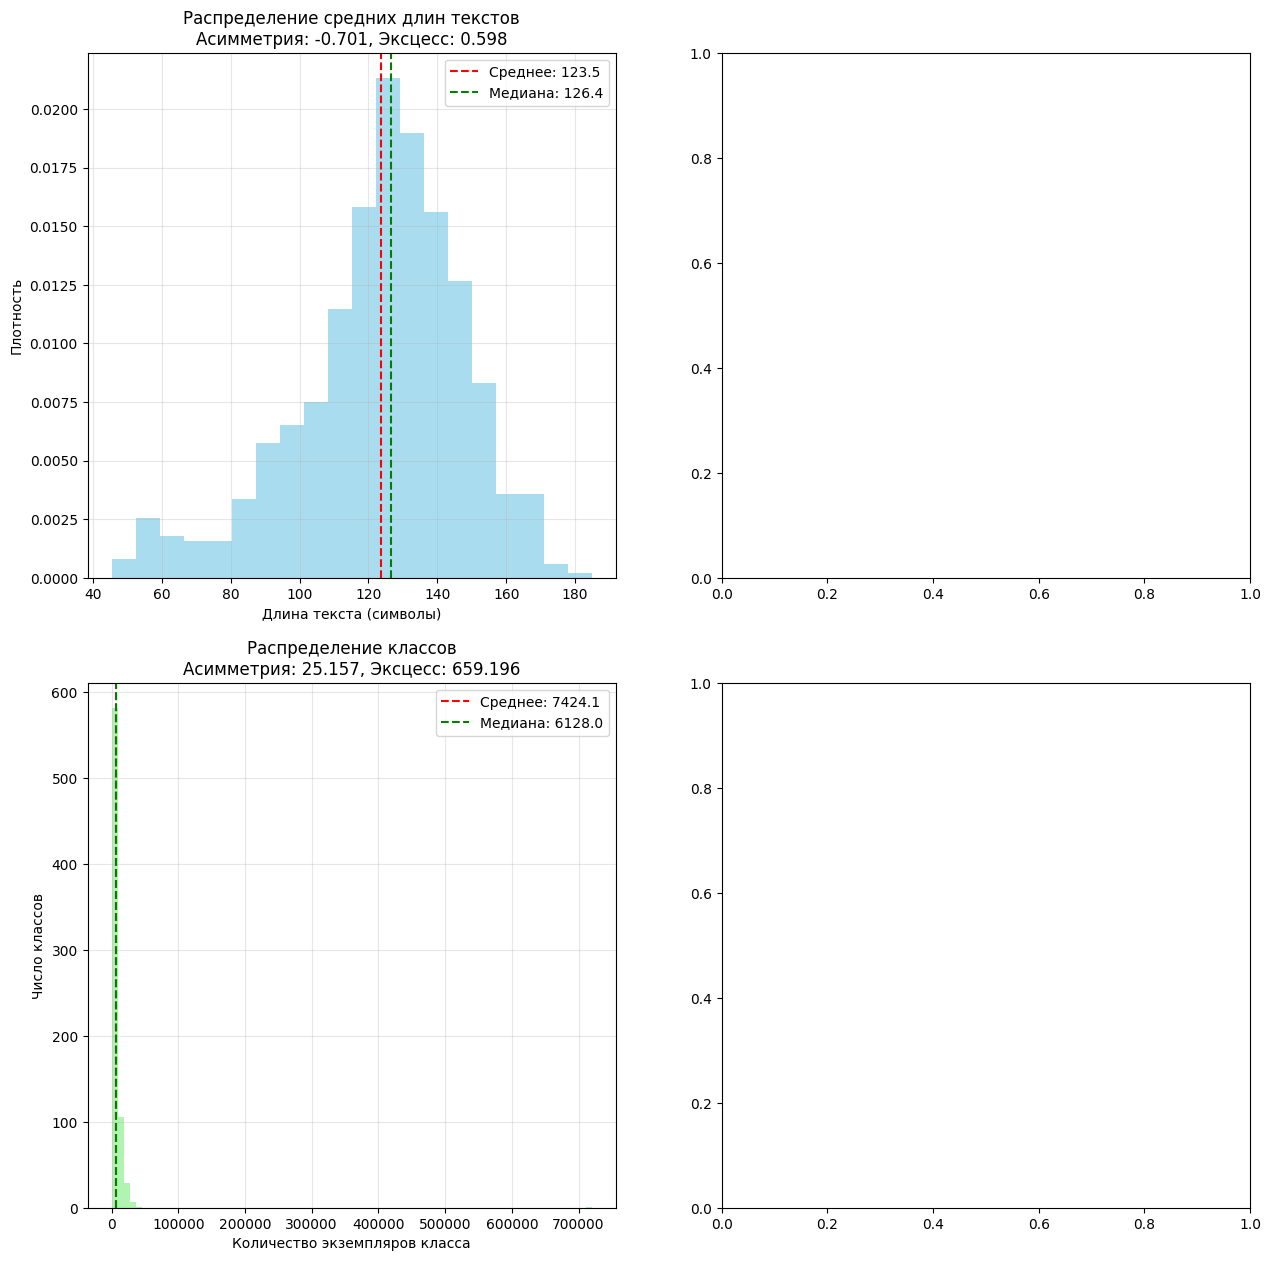

In [257]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# Гистограмма средних длин текстов
axes[0,0].hist(avg_lens, bins=20, alpha=0.7, color='skyblue', density=True)
# sns.histplot(lens, kde=True,
#              bins=50, color = 'skyblue', 
#              ax=axes[0,0])
axes[0,0].axvline(avg_lens.mean(), color='red', linestyle='--', 
                 label=f'Среднее: {avg_lens.mean():.1f}')
axes[0,0].axvline(avg_lens.median(), color='green', linestyle='--', 
                 label=f'Медиана: {avg_lens.median():.1f}')


axes[0,0].set_title(f'Распределение средних длин текстов\nАсимметрия: {stats.skew(avg_lens):.3f}, Эксцесс: {stats.kurtosis(avg_lens):.3f}')
axes[0,0].set_xlabel('Длина текста (символы)')
axes[0,0].set_ylabel('Плотность')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# # Гистограмма количества слов
# axes[0,1].hist(words_count, bins=150, alpha=0.7, color='lightgreen', density=True)
# axes[0,1].axvline(words_count.mean(), color='red', linestyle='--', 
#                  label=f'Среднее: {words_count.mean():.1f}')
# axes[0,1].axvline(words_count.median(), color='green', linestyle='--', 
#                  label=f'Медиана: {words_count.median():.1f}')
# axes[0,1].set_title(f'Распределение количества слов\nАсимметрия: {stats.skew(words_count):.3f}, Эксцесс: {stats.kurtosis(words_count):.3f}')
# axes[0,1].set_xlabel('Количество слов')
# axes[0,1].set_ylabel('Плотность')
# axes[0,1].legend()
# axes[0,1].grid(True, alpha=0.3)

# Гистограмма классов
axes[1,0].hist(vc, bins=80, alpha=0.7, color='lightgreen', density=False)
axes[1,0].axvline(vc.mean(), color='red', linestyle='--', 
                 label=f'Среднее: {vc.mean():.1f}')
axes[1,0].axvline(vc.median(), color='green', linestyle='--', 
                 label=f'Медиана: {vc.median():.1f}')
axes[1,0].set_title(f'Распределение классов\nАсимметрия: {stats.skew(vc):.3f}, Эксцесс: {stats.kurtosis(vc):.3f}')
axes[1,0].set_xlabel('Количество экземпляров класса')
axes[1,0].set_ylabel('Число классов')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

In [264]:
corr = pd.DataFrame()
corr['avg_lens'] = avg_lens

In [267]:
mm = list(map(lambda x: types_name.index(x), df['category_name']))

In [273]:
corr['category_name'] = [i for i in range(len(avg_lens))]

In [274]:
corr_len_cn = corr.corr(method='pearson')
corr_len_cn

,avg_lens,category_name
avg_lens,1.000000,0.057937
category_name,0.057937,1.000000


In [275]:
corr

,avg_lens,category_name
0,118.151006,0
1,105.109534,1
2,60.466337,2
3,87.359636,3
4,63.403705,4
...,...,...
721,79.079570,721
722,55.220017,722
723,107.619264,723
724,112.719102,724


0      118.151006
1      105.109534
2       60.466337
3       87.359636
4       63.403705
          ...    
721     79.079570
722     55.220017
723    107.619264
724    112.719102
725    184.889468
Length: 726, dtype: float64

In [278]:
types

array([['Sports & Outdoors', 720050],
       ['Baby', 36154],
       ["Men's Shoes", 32143],
       ...,
       ['Smart Speakers', 25],
       ['Smart Home Thermostats - Compatibility Checker', 22],
       ['Cameras', 12]], shape=(726, 2), dtype=object)

In [281]:
np.where(df['category_name'].to_numpy() == 'Sports & Outdoors')

(array([2144374, 2144375, 2144376, ..., 5037333, 5037334, 5037335],
       shape=(720050,)),)

In [284]:
S = 0
for title in df['title'].to_numpy()[np.where(df['category_name'].to_numpy() == 'Sports & Outdoors')]:
    S += len(title)

In [286]:
S/720050

118.15084230261787